## Calving series methodology for Jakobshavn Isbrae ##

This notebook is the first copy of deriving a calving time series for glacier Jakobshavn Isbrae in Greenland. 

This notebook develops a __calving time series__ using:
1. satellite-derived terminus positions
2. surface velocity near the terminnus, and 
3. different metrics of terminus change

Where __length change__, is measured along the centerline, a common proxy for average glacier retreat; and __area change__ is across the full width of the glacier, capturing along-terminus variability and asymmetric calving behavior.



#### 1. Set up notebook and load in data ####

In [1]:
# Notebook set up: import dependencies and packages
# Run this on greenlandMapping 
%load_ext autoreload
%autoreload 2
import os
import dask
import panel
import pandas as pd
import matplotlib.pyplot as plt
import nisardev as nisar
import grimpfunc as grimp
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import geopandas as gpd
import glob
import shapely
import rasterio
import geopandas as gpd
from shapely.geometry import LineString
from shapely.geometry import Polygon
from shapely.affinity import translate
from shapely.ops import split
from dask.diagnostics import ProgressBar
from shapely.geometry import Point
import matplotlib.ticker as mticker
from shapely.ops import linemerge, unary_union


In [2]:
#paths
centreline_path = "/Users/sofiasuhinin/Desktop/GrIS_Calving/flowlines/glacier0001_iter03.shp"
centerline_extended_path = "/Users/sofiasuhinin/Desktop/GrIS_Calving/flowlines/jakobshavn_centreline_ss.shp"
terminus_path = "/Users/sofiasuhinin/Desktop/GrIS_Calving/data/MEaSUREs_0781/collated/JakbobshavnIsbraeTerminus.shp"
velocity_path = "/Users/sofiasuhinin/Desktop/GrIS_Calving/data/MEaSUREs_0766/JakobshavnIsbraeVelocitySeriesNew.nc"

#read in velocity 
velocity = xr.open_dataset(velocity_path)

#read in centreline + make sure coordinate system = EPSG:3413
centerline = gpd.read_file(centreline_path)
centerline = centerline.to_crs("EPSG:3413")
centerline_shape = centerline.geometry.iloc[0]

# read in extended centreline and make sure coordinate system = EPSG:3413
centerline_extended = gpd.read_file(centerline_extended_path)
centerline_extended = centerline_extended.to_crs("EPSG:3413")

# merge extended centreline into 1 geometry
c_merged = linemerge(unary_union(centerline_extended.geometry))
centerline_extended = gpd.GeoDataFrame(geometry=[c_merged], crs=centerline_extended.crs)
centerline_extended_shape = centerline_extended.geometry.iloc[0]

# fixing the order of the geometries bc apparently its possible to do it backwards! 
parts = list(centerline_extended_shape.geoms)
main = parts[2]
extension = parts[0]
coords = list(extension.coords)[::-1] + list(main.coords)
centerline_extended_shape = LineString(coords)

#sanity check for geospatial alignment
print(centerline.crs)
print(centerline_extended.crs)

#read in terminus
terminus = gpd.read_file(terminus_path)
terminus = terminus.to_crs("EPSG:3413")

#sanity check for geospatial alignment
print(terminus.crs)

EPSG:3413
EPSG:3413
EPSG:3413


In [3]:
terminus

,Image_ID,Image_Tile,SourceDate,Quality_Fl,Glacier_ID,geometry
0,SEN1_NSIDC_0723_V2_20160201_20160212,S1A_090_009787,2016-02-03,0,3,"LINESTRING (-184523.658 -2277242.523, -184005...."
1,SEN1_NSIDC_0723_V2_20170201_20170206,S1B_090_004141,2017-02-03,1,3,"LINESTRING (-185836.057 -2276614.059, -185698...."
2,SEN1_NSIDC_0723_V2_20190215_20190220,S1B_090_014991,2019-02-17,1,3,"LINESTRING (-185915.432 -2276582.309, -185957...."
3,SEN1_NSIDC_0723_V2_20150101_20150112,S1A_090_004012,2015-01-03,0,3,"LINESTRING (-188606.112 -2265922.891, -188399...."
4,SEN1_NSIDC_0723_V2_20150113_20150124,S1A_090_004187,2015-01-15,1,3,"LINESTRING (-188634.464 -2265910.404, -188629...."
...,...,...,...,...,...,...
352,SEN1_NSIDC_0723_V4_20211201_20211206,S1B_090_029866,2021-12-03,1,3,"LINESTRING (-185164.014 -2276666.976, -184867...."
353,SEN1_NSIDC_0723_V4_20211207_20211212,S1A_090_040937,2021-12-09,1,3,"LINESTRING (-184931.18 -2276910.393, -184380.8..."
354,SEN1_NSIDC_0723_V4_20211213_20211218,S1B_090_030041,2021-12-15,1,3,"LINESTRING (-184793.596 -2276973.893, -184497...."
355,SEN1_NSIDC_0723_V4_20211219_20211224,S1A_090_041112,2021-12-21,1,3,"LINESTRING (-184719.513 -2277016.227, -184391...."


In [4]:
#cleaning
terminus = terminus.rename(columns={"SourceDate": "Date", "Quality_Fl" : "Flag"}) #rename for simplicity
terminus["Date"] = pd.to_datetime(terminus["Date"]) #make sure it is in datetime 
terminus = terminus.sort_values(by = 'Date')
terminus.drop_duplicates(subset = ['Glacier_ID', 'Date'], keep = 'first') #drop duplicates

,Image_ID,Image_Tile,Date,Flag,Glacier_ID,geometry
3,SEN1_NSIDC_0723_V2_20150101_20150112,S1A_090_004012,2015-01-03,0,3,"LINESTRING (-188606.112 -2265922.891, -188399...."
4,SEN1_NSIDC_0723_V2_20150113_20150124,S1A_090_004187,2015-01-15,1,3,"LINESTRING (-188634.464 -2265910.404, -188629...."
5,SEN1_NSIDC_0723_V2_20150125_20150205,S1A_090_004362,2015-01-27,1,3,"LINESTRING (-186068.771 -2276605.242, -185814...."
6,SEN1_NSIDC_0723_V2_20150206_20150217,S1A_090_004537,2015-02-08,0,3,"LINESTRING (-184745.971 -2277111.477, -184132...."
17,SEN1_NSIDC_0723_V4_20150218_20150301,S1A_090_004712,2015-02-20,0,3,"LINESTRING (-185068.764 -2276846.893, -184507...."
...,...,...,...,...,...,...
351,SEN1_NSIDC_0723_V4_20211125_20211130,S1A_090_040762,2021-11-27,0,3,"LINESTRING (-185111.097 -2276688.143, -184878...."
352,SEN1_NSIDC_0723_V4_20211201_20211206,S1B_090_029866,2021-12-03,1,3,"LINESTRING (-185164.014 -2276666.976, -184867...."
353,SEN1_NSIDC_0723_V4_20211207_20211212,S1A_090_040937,2021-12-09,1,3,"LINESTRING (-184931.18 -2276910.393, -184380.8..."
354,SEN1_NSIDC_0723_V4_20211213_20211218,S1B_090_030041,2021-12-15,1,3,"LINESTRING (-184793.596 -2276973.893, -184497...."


In [5]:
print(terminus["Date"].min())
print(terminus["Date"].max())

print(velocity["time"].values.min())
print(velocity["time"].values.max())

2015-01-03 00:00:00
2021-12-21 00:00:00
2015-01-06T12:00:00.000000000
2024-12-14T12:00:00.000000000


##### 2. Data visualisation / spatial verification ####
*What does the velocity data look like? Are the centreline and terminus geometries aligned?* 


In these cells I want to inspect the spatial coverage of the valid velocity observations across all the data, this will be helpful in seeing how much valid velocity data I do have for my time series. 

In [6]:
#plotting configurations
# colors
dark_blue = "#1f3a5f"
light_blue = "#6baed6"

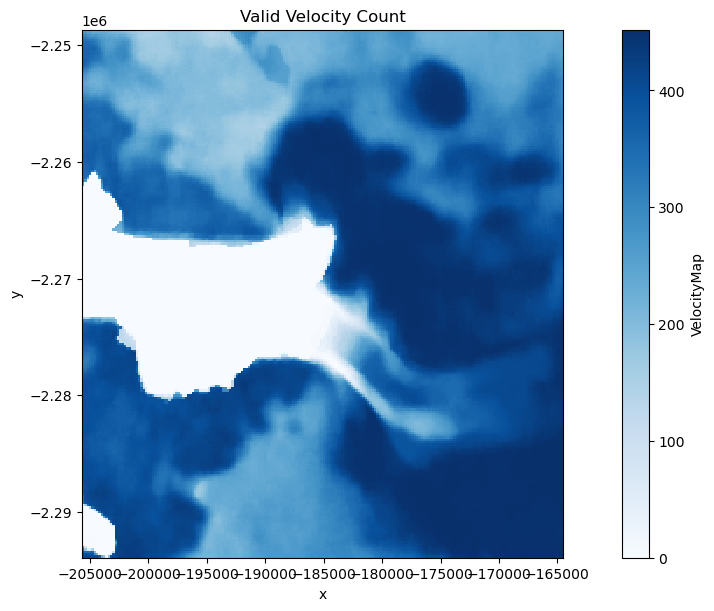

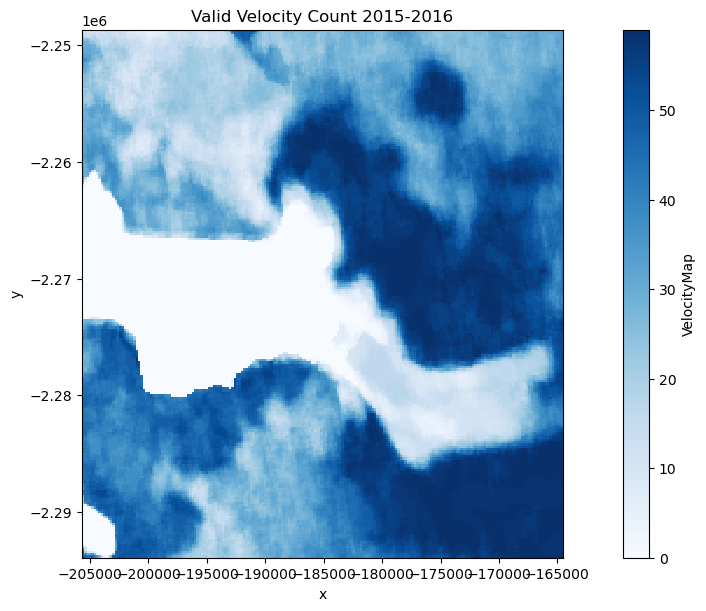

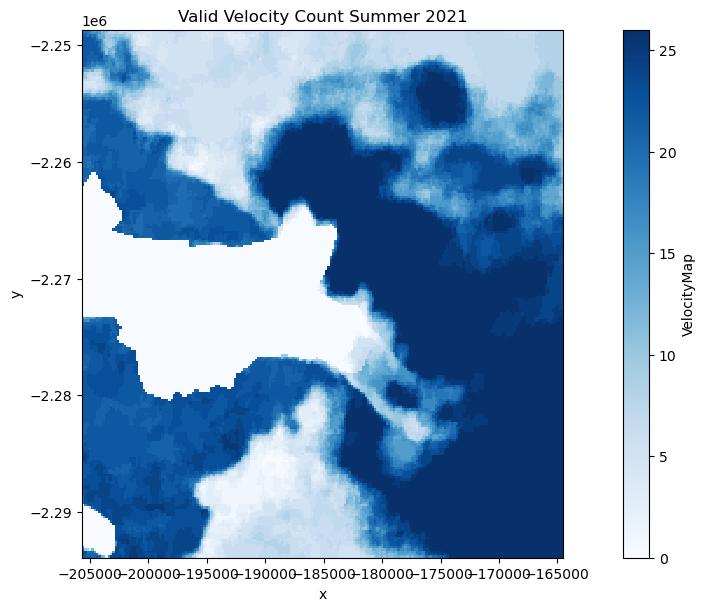

In [7]:
#preparing velocity data for plotting
x_vals = velocity["x"].values
y_vals = velocity["y"].values

vel_band = velocity["VelocityMap"].isel(band=2).assign_coords(
    x=("x", x_vals),
    y=("y", y_vals),
)
vel_times = pd.to_datetime(vel_band["time"].values)

valid_count = vel_band.count(dim="time")  #points with "valid" non NaN values

fig, ax = plt.subplots(1, figsize=(8, 6), constrained_layout=True)

#Figure 1: Valid velocity count across all time steps
valid_count.plot(
    ax=ax,
    x="x",
    y="y",
    cmap = "Blues", 
    add_colorbar=True,
)
ax.set_title("Valid Velocity Count")
ax.set_aspect("equal")


#Figure 2: Valid velocity count from 2015-2016 

valid_count_2015_2016 = vel_band.sel(time=slice("2015-01-01", "2016-12-31")).count(dim="time")

fig, ax = plt.subplots(1, figsize=(8, 6), constrained_layout=True)

valid_count_2015_2016.plot(
    ax=ax,
    x="x",
    y="y",
    cmap = "Blues",
    add_colorbar=True,
)
ax.set_title("Valid Velocity Count 2015-2016")
ax.set_aspect("equal")


#figure 3: valid velocity summer 2021

valid_count_2021 = (vel_band.sel(time=slice("2021-04-01", "2021-08-31")).count(dim="time"))

fig, ax = plt.subplots(1, figsize=(8, 6), constrained_layout=True)

valid_count_2021.plot(
    ax=ax,
    x="x",
    y="y",
    cmap = "Blues",
    add_colorbar=True,
)
ax.set_title("Valid Velocity Count Summer 2021")
ax.set_aspect("equal")

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


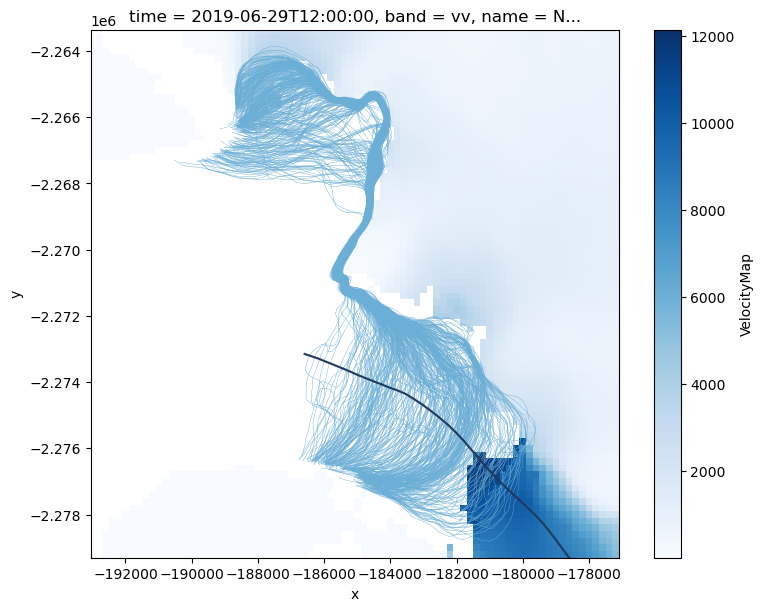

In [8]:
# Plot a representative velocity slice together with terminus geometries and the extended centerline

# preparing velocity data for plotting
x_vals = velocity["x"].values
y_vals = velocity["y"].values

vel_band = velocity["VelocityMap"].isel(band=2).assign_coords(
    x=("x", x_vals),
    y=("y", y_vals),
)
vel_times = pd.to_datetime(vel_band["time"].values)

valid_count = vel_band.count(dim="time")  # points with valid non-NaN values

sampletime = 220
vel_slice = velocity["VelocityMap"].isel(band=2, time=sampletime)

# preparing centerline for plotting
centreline_gs_ext = gpd.GeoSeries([centerline_extended_shape], crs=terminus.crs)

fig, ax = plt.subplots(1, figsize=(8, 6), constrained_layout=True)

# 1: velocity with terminus and extended centerline
vel_slice.plot(ax=ax,x="x",y="y",cmap="Blues",add_colorbar=True)
terminus.plot(ax=ax,facecolor="none",edgecolor=light_blue,linewidth=0.3)
centreline_gs_ext.plot(ax=ax,color=dark_blue,linewidth=1.5)

# zoom in to see intersection better
xmin, ymin, xmax, ymax = terminus.total_bounds
zoom = 500

ax.set_xlim(xmin - zoom, xmax + zoom)
ax.set_ylim(ymin - zoom, ymax + zoom)
ax.set_box_aspect(1)

plt.show()

velocity: 2017-09-25 12:00:00
terminus: 2017-09-25 00:00:00
velocity: 2020-10-21 12:00:00
terminus: 2020-10-21 00:00:00


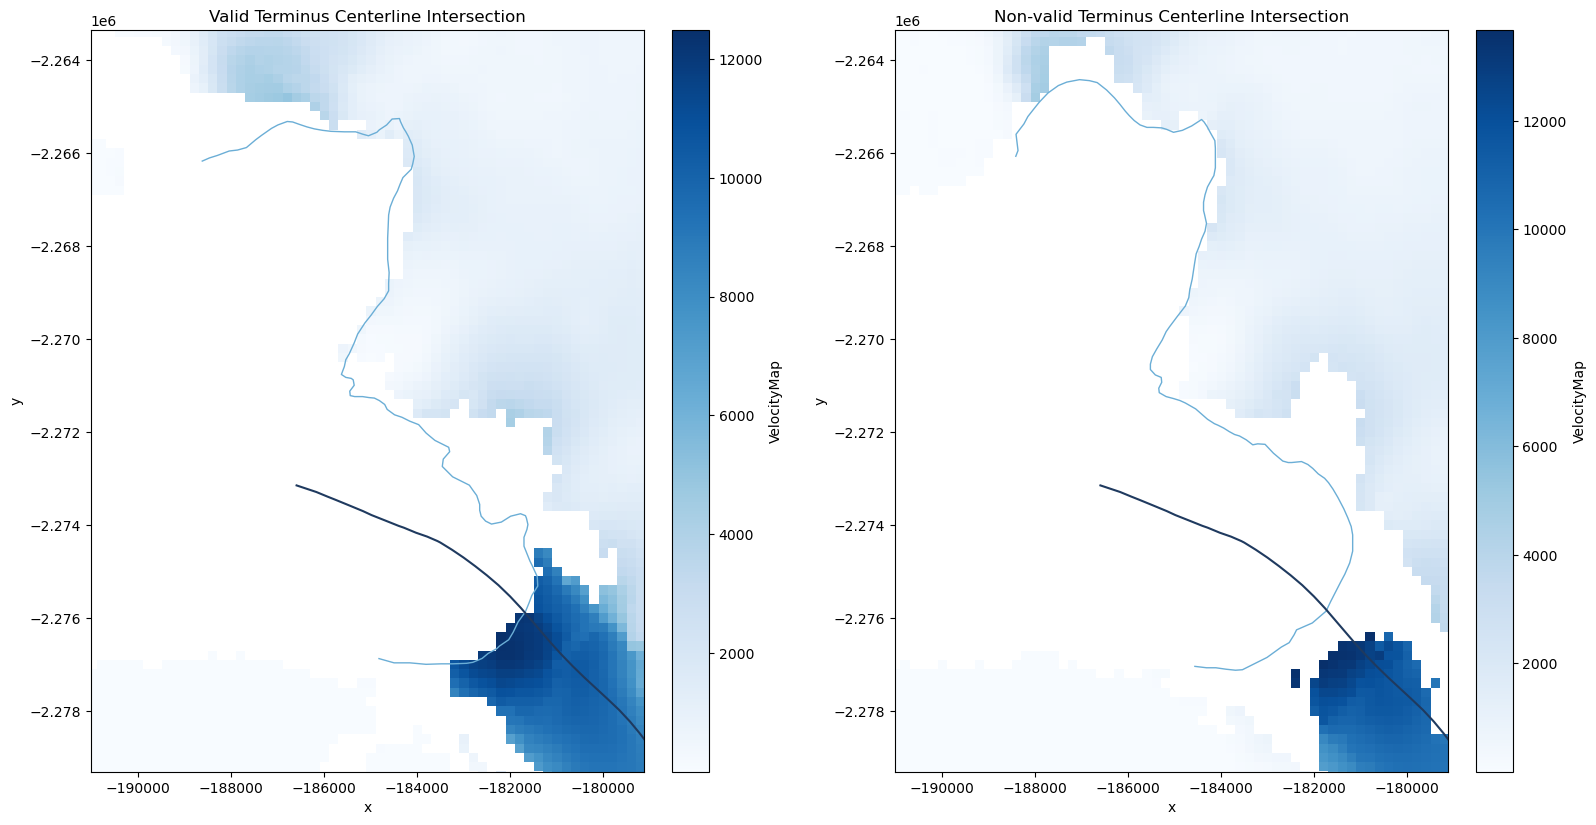

In [9]:
# visualising velocity, terminus and EXTENDED centerline on one with a VALID intersection value
# velocity: 2017-10-01 12:00:00
# terminus: 2017-10-01 00:00:00

sampletime1 = 113

vel_time = velocity["time"].isel(time=sampletime1).values
nearest_time = (terminus["Date"] - vel_time).abs().idxmin()  # nearest terminus date to velocity time
term_time = terminus.loc[[nearest_time]]

vel_slice = velocity["VelocityMap"].isel(band=2, time=sampletime1)

t_vel = pd.to_datetime(vel_time)
t_term = term_time["Date"].iloc[0]
print("velocity:", t_vel)
print("terminus:", t_term)

vel_slice = vel_slice.assign_coords(
    x=("x", x_vals),
    y=("y", y_vals),
)

nrow, ncol = (1, 2)

fig, ax = plt.subplots(
    figsize=(16, 14),
    layout="compressed",
    nrows=nrow,
    ncols=ncol,
)

vel_slice.plot(
    ax=ax[0],
    x="x",
    y="y",
    cmap="Blues",
    add_colorbar=True,
)

term_time.plot(
    ax=ax[0],
    facecolor="none",
    edgecolor=light_blue,
    linewidth=1,
)

centreline_gs_ext = gpd.GeoSeries(
    [centerline_extended_shape],
    crs=terminus.crs if hasattr(terminus, "crs") else None
)
centreline_gs_ext.plot(
    ax=ax[0],
    color=dark_blue,
    linewidth=1.5,
)

# visualising velocity, terminus and EXTENDED centerline on one with a NON-VALID intersection value
sampletime2 = 300

vel_time = velocity["time"].isel(time=sampletime2).values
nearest_time = (terminus["Date"] - vel_time).abs().idxmin()
term_time = terminus.loc[[nearest_time]]

vel_slice = velocity["VelocityMap"].isel(band=2, time=sampletime2)

# check: are these the same day / near?
t_vel = pd.to_datetime(vel_time)
t_term = term_time["Date"].iloc[0]
print("velocity:", t_vel)
print("terminus:", t_term)

vel_slice = vel_slice.assign_coords(
    x=("x", x_vals),
    y=("y", y_vals),
)

vel_slice.plot(
    ax=ax[1],
    x="x",
    y="y",
    cmap="Blues",
    add_colorbar=True,
)

term_time.plot(
    ax=ax[1],
    facecolor="none",
    edgecolor=light_blue,
    linewidth=1,
)

centreline_gs_ext.plot(
    ax=ax[1],
    color=dark_blue,
    linewidth=1.5,
)

# zoom in order to see intersection better
xmin, ymin, xmax, ymax = terminus.total_bounds
zoom = 500

for a in ax:
    a.set_xlim(xmin - zoom, xmax + zoom)
    a.set_ylim(ymin - zoom, ymax + zoom)

ax[0].set_title("Valid Terminus Centerline Intersection")
ax[1].set_title("Non-valid Terminus Centerline Intersection")

plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


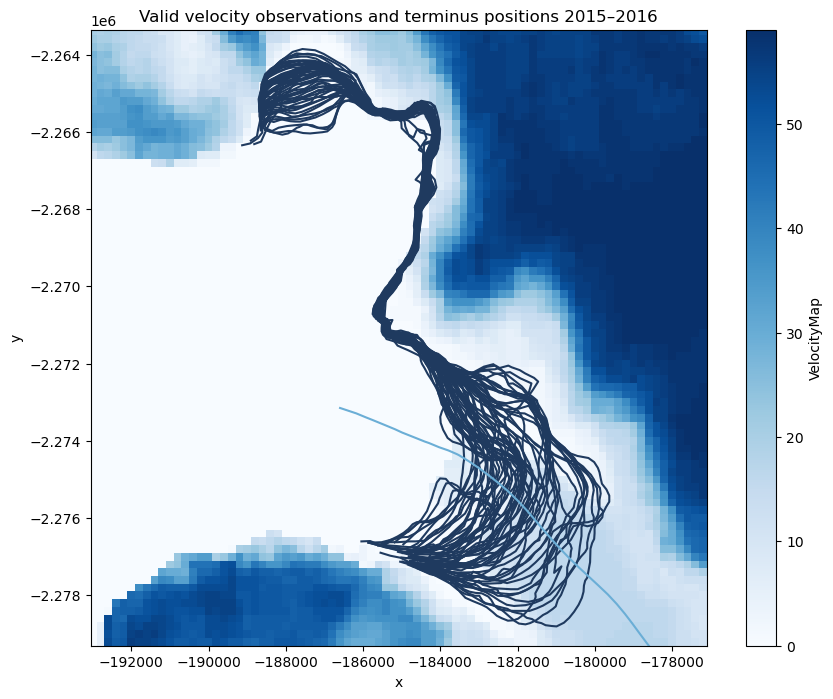

In [10]:
valid_count_2015_2016 = (vel_band.sel(time=slice("2015-01-01", "2016-12-31")).count(dim="time"))

term_2015_2016 = terminus[((terminus["Date"]) >= "2015-01-01") & ((terminus["Date"]) <= "2016-12-31")]

fig, ax = plt.subplots(figsize=(10, 8))

valid_count_2015_2016.plot(ax=ax,cmap="Blues")
term_2015_2016.plot(ax=ax,color=dark_blue)
centreline_gs_ext.plot(ax=ax,color=light_blue,linewidth=1.5)

ax.set_title("Valid velocity observations and terminus positions 2015–2016")

xmin, ymin, xmax, ymax = terminus.total_bounds
zoom = 500
ax.set_xlim(xmin - zoom, xmax + zoom)
ax.set_ylim(ymin - zoom, ymax + zoom)
ax.set_box_aspect(1)

plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


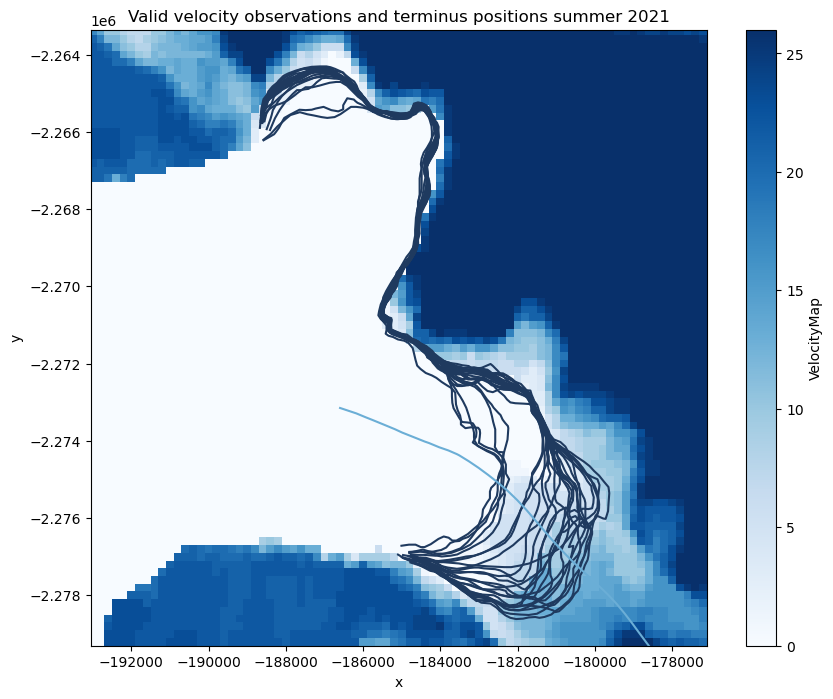

In [11]:
valid_count_2021 = (vel_band.sel(time=slice("2021-04-01", "2021-08-31")).count(dim="time"))
term_2021 = terminus[((terminus["Date"]) >= "2021-04-01") & ((terminus["Date"]) <= "2021-08-31")]

fig, ax = plt.subplots(figsize=(10, 8))

valid_count_2021.plot(ax=ax,cmap="Blues")
term_2021.plot(ax=ax,color=dark_blue)
centreline_gs_ext.plot(ax=ax,color=light_blue,linewidth=1.5)

ax.set_title("Valid velocity observations and terminus positions summer 2021")


xmin, ymin, xmax, ymax = terminus.total_bounds
zoom = 500

ax.set_xlim(xmin - zoom, xmax + zoom)
ax.set_ylim(ymin - zoom, ymax + zoom)
ax.set_box_aspect(1)

plt.show()

In [12]:
# look date by date at velocity maps and terminus positions 

def plot_vel(sampletime, ax, title):
    vel_time = velocity["time"].isel(time=sampletime).values
    nearest_time = (terminus["Date"] - vel_time).abs().idxmin()
    term_time = terminus.loc[[nearest_time]]
    vel_slice = (velocity["VelocityMap"].isel(band=2, time=sampletime).assign_coords(x=("x", x_vals), y=("y", y_vals)))

    print("velocity:", pd.to_datetime(vel_time))
    print("terminus:", term_time["Date"].iloc[0])

    vel_slice.plot(ax=ax,x="x",y="y",cmap="Blues",add_colorbar=True)
    term_time.plot(ax=ax,facecolor="none",edgecolor=light_blue,linewidth=1)
    centreline_gs_ext.plot(ax=ax,color=dark_blue,linewidth=1.5)

    ax.set_title(title)

In [13]:
# commenting this out for now bc it takes ages to run
# 2015-2016
# centreline_gs_ext = gpd.GeoSeries([centerline_extended_shape],crs=terminus.crs if hasattr(terminus, "crs") else None)

# sampletimes = range(0, 75)

# fig, ax = plt.subplots(nrows=len(sampletimes),ncols=1,figsize=(10, 4 * len(sampletimes)))

# xmin, ymin, xmax, ymax = terminus.total_bounds
# zoom = 500

# for a, sampletime in zip(ax, sampletimes):
#     vel_time = pd.to_datetime(velocity["time"].isel(time=sampletime).values)
#     plot_vel(sampletime=sampletime,ax=a,title=f"{sampletime}: {vel_time:%Y-%m-%d}")
#     a.set_xlim(xmin - zoom, xmax + zoom)
#     a.set_ylim(ymin - zoom, ymax + zoom)

# plt.tight_layout()
# plt.show()

In [14]:
# commenting this out for now bc it takes ages to run
# summer 2021, 04-19 --> 09-16
# centreline_gs_ext = gpd.GeoSeries([centerline_extended_shape],crs=terminus.crs if hasattr(terminus, "crs") else None)

# sampletimes = range(330, 356)

# fig, ax = plt.subplots(nrows=len(sampletimes),ncols=1,figsize=(10, 4 * len(sampletimes)))

# xmin, ymin, xmax, ymax = terminus.total_bounds
# zoom = 500

# for a, sampletime in zip(ax, sampletimes):
#     vel_time = pd.to_datetime(velocity["time"].isel(time=sampletime).values)
#     plot_vel(sampletime=sampletime,ax=a,title=f"{sampletime}: {vel_time:%Y-%m-%d}")
#     a.set_xlim(xmin - zoom, xmax + zoom)
#     a.set_ylim(ymin - zoom, ymax + zoom)

# plt.tight_layout()
# plt.show()

### Step 1: Finding centreline and terminus intersection 

In [15]:
# finding the intersection between the centerline and the terminus
def intersection(centreline, terminus_line):
    intersect = centreline.intersection(terminus_line)

    if intersect.is_empty:
        return None
    
    if intersect.geom_type == "MultiPoint": #if there is more than one intersect put the point closes to the centre of the terminus line
        return min(intersect.geoms, key = lambda p: p.distance(terminus_line.centroid))
    
    return intersect
 
pts = []
for i in range(len(terminus)):
    terminus_line = terminus.geometry.iloc[i]
    pt = intersection(centerline_extended_shape, terminus_line) #geometric intersection between centerline_shape and terminus_line 
    pts.append(pt)

terminus["intersect_points"] = pts

#check to see how many are NaN (i.e. no valid intersection)
none_vals = terminus["intersect_points"].isna().sum()
print(f"Number of NaN intersection points: {none_vals}")

#check to see how many are non NaN (i.e. valid intersection)
valid_vals = terminus["intersect_points"].notna().sum()
print(f"Number of valid intersection points: {valid_vals} out of {len(terminus)}")


Number of NaN intersection points: 0
Number of valid intersection points: 357 out of 357


### Step 2: Sample velocity at X m away from the intersection
- Using a consistent simple velocity extraction method
- As a comparison add a list that is velocity at intersection
- __Edit: If NaN at 1500m, then sample at 2000m, if still NaN then skip__

In [16]:
upstream_m = 1500

vel_at_intersection = []
vel_up_centreline = []

for i in range(len(terminus)):
    pt = terminus["intersect_points"].iloc[i]
    t_term = pd.to_datetime(terminus["Date"].iloc[i])

    if pt is None:
        vel_at_intersection.append(np.nan)
        vel_up_centreline.append(np.nan)
        continue

    vel_slice = vel_band.sel(time=t_term, method="nearest")

    # velocity at intersection
    v0 = vel_slice.sel(x=pt.x, y=pt.y, method="nearest").values
    vel_at_intersection.append(float(v0) if np.isfinite(v0) else np.nan)

    # velocity upstream along the same extended centreline
    d0 = centerline_extended_shape.project(pt)

    v1 = np.nan

    for upstream_m in [1500, 2000]:
        d1 = d0 + upstream_m

        if d1 > centerline_extended_shape.length:
            continue
        p1 = centerline_extended_shape.interpolate(float(d1))
        v_test = vel_slice.sel(x=p1.x,y=p1.y,method="nearest").values

        if np.isfinite(v_test):
            v1 = float(v_test)
            break
    vel_up_centreline.append(v1)

terminus["vel_at_intersection"] = vel_at_intersection
terminus["vel_up_centreline"] = vel_up_centreline

In [17]:
print(terminus["vel_up_centreline"].isna().sum())

61


In [18]:
# -- Optional Smoothing and interpolation of velocity upstream of the centerline intersection --
#smoothed and interpolated velocity upstream of the centerline intersection
#window = "12D"  # 12-day rolling window
#smoothing = terminus.set_index("Date")["vel_up_centreline"].sort_index()
#smoothed = smoothing.rolling(window=window, min_periods=1, center=True).mean()
#smoothed_interp = smoothed.interpolate(method="time", limit=5)
#terminus["vel_up_smoothed_interp"] = smoothed_interp.reindex(terminus["Date"]).to_numpy()

print(f"Number of valid values in vel_at_intersection: {terminus['vel_at_intersection'].notna().sum()} out of {len(terminus)}")
print(f"Number of valid values in vel_up_centreline: {terminus['vel_up_centreline'].notna().sum()} out of {len(terminus)}")
#print(f"Number of valid values in vel_up_smoothed_interp: {terminus['vel_up_smoothed_interp'].notna().sum()} out of {len(terminus)}")

Number of valid values in vel_at_intersection: 52 out of 357
Number of valid values in vel_up_centreline: 296 out of 357


In [19]:
print(terminus[["Date", "vel_up_centreline"]].iloc[0:50])

         Date  vel_up_centreline
3  2015-01-03                NaN
4  2015-01-15                NaN
5  2015-01-27                NaN
6  2015-02-08                NaN
17 2015-02-20                NaN
18 2015-03-04                NaN
19 2015-03-16                NaN
20 2015-03-28                NaN
21 2015-04-09                NaN
22 2015-04-21                NaN
23 2015-05-03                NaN
24 2015-05-15                NaN
25 2015-05-27                NaN
7  2015-06-08                NaN
26 2015-07-26                NaN
8  2015-08-07                NaN
27 2015-08-19                NaN
28 2015-08-31                NaN
29 2015-09-12                NaN
30 2015-10-18                NaN
9  2015-11-11                NaN
31 2015-11-23                NaN
32 2015-12-05                NaN
33 2015-12-17                NaN
34 2015-12-29                NaN
35 2016-01-10                NaN
36 2016-01-22                NaN
0  2016-02-03                NaN
37 2016-02-15                NaN
38 2016-02

velocity time: 2019-06-29T12:00:00.000000000


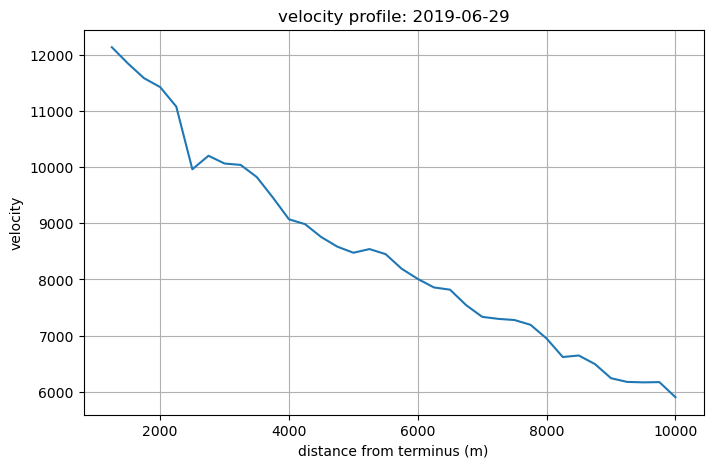

In [20]:
# Take one date, and then take the velocity value from the terminus/centerline intersection
# and then keep shifting up 250 m increments up the centerline to around 10 000 m up to see the velocity profile
	# Do one in summer
	# Do one in winter

## summer 2019-06-29
sampletime = 220 # 2019-06-29

vel_time = velocity["time"].isel(time=sampletime).values
nearest_time = (terminus["Date"] - vel_time).abs().idxmin() #nearest terminus date to vel time
print("velocity time:", vel_time)

start = terminus.loc[nearest_time, "intersect_points"]
start_dist = centerline_extended_shape.project(start)

# move upstream every 250 m to 10 000 m 
dist_upstream = np.arange(0, 10000 + 250, 250)
points = [centerline_extended_shape.interpolate(start_dist + d) for d in dist_upstream]

# get velocity slice
vel_slice = (velocity["VelocityMap"].isel(band=2, time=sampletime).assign_coords(x=("x", x_vals), y=("y", y_vals)))

# sample velocity at each point
vel_profile = [vel_slice.sel(x=pt.x, y=pt.y, method="nearest").item() for pt in points]

# plot
plt.figure(figsize=(8, 5))
plt.plot(dist_upstream, vel_profile)
plt.xlabel("distance from terminus (m)")
plt.ylabel("velocity")
plt.title(f"velocity profile: 2019-06-29")
plt.grid(True)
plt.show()

velocity time: 2020-01-25T12:00:00.000000000


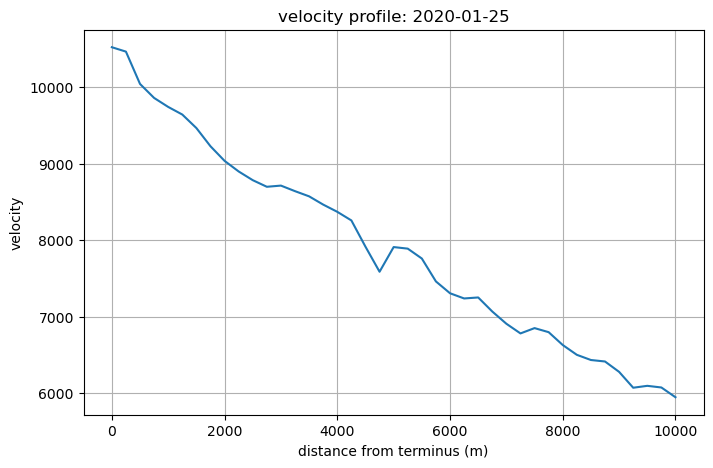

In [21]:
# winter 

sampletime = 255 # 2020-01-25

vel_time = velocity["time"].isel(time=sampletime).values
nearest_time = (terminus["Date"] - vel_time).abs().idxmin() #nearest terminus date to vel time
print("velocity time:", vel_time)

start = terminus.loc[nearest_time, "intersect_points"]
start_dist = centerline_extended_shape.project(start)

dist_upstream = np.arange(0, 10000 + 250, 250)
points = [centerline_extended_shape.interpolate(start_dist + d) for d in dist_upstream]

# get velocity slice
vel_slice = (velocity["VelocityMap"].isel(band=2, time=sampletime).assign_coords(x=("x", x_vals), y=("y", y_vals)))

# sample velocity at each point
vel_profile = [vel_slice.sel(x=pt.x, y=pt.y, method="nearest").item() for pt in points]

# plot
plt.figure(figsize=(8, 5))
plt.plot(dist_upstream, vel_profile)
plt.xlabel("distance from terminus (m)")
plt.ylabel("velocity")
plt.title(f"velocity profile: 2020-01-25")
plt.grid(True)
plt.show()

velocity time: 2016-09-21T12:00:00.000000000


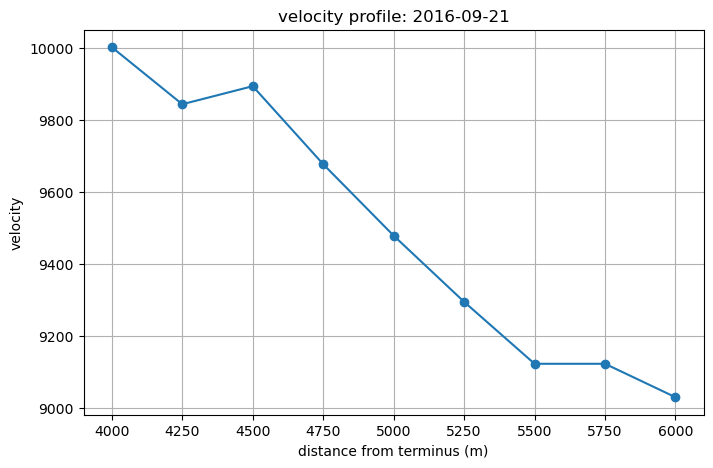

In [22]:
# 2016 - 09 - 21

sampletime = 52

vel_time = velocity["time"].isel(time=sampletime).values
nearest_time = (terminus["Date"] - vel_time).abs().idxmin() #nearest terminus date to vel time
print("velocity time:", vel_time)

start = terminus.loc[nearest_time, "intersect_points"]
start_dist = centerline_extended_shape.project(start)

dist_upstream = np.arange(0, 10000 + 250, 250)
points = [centerline_extended_shape.interpolate(start_dist + d) for d in dist_upstream]

# get velocity slice
vel_slice = (velocity["VelocityMap"].isel(band=2, time=sampletime).assign_coords(x=("x", x_vals), y=("y", y_vals)))

# sample velocity at each point
vel_profile = [vel_slice.sel(x=pt.x, y=pt.y, method="nearest").item() for pt in points]

# plot
plt.figure(figsize=(8, 5))
plt.plot(dist_upstream, vel_profile, marker = "o")
plt.xlabel("distance from terminus (m)")
plt.ylabel("velocity")
plt.title(f"velocity profile: 2016-09-21")
plt.grid(True)
plt.show()

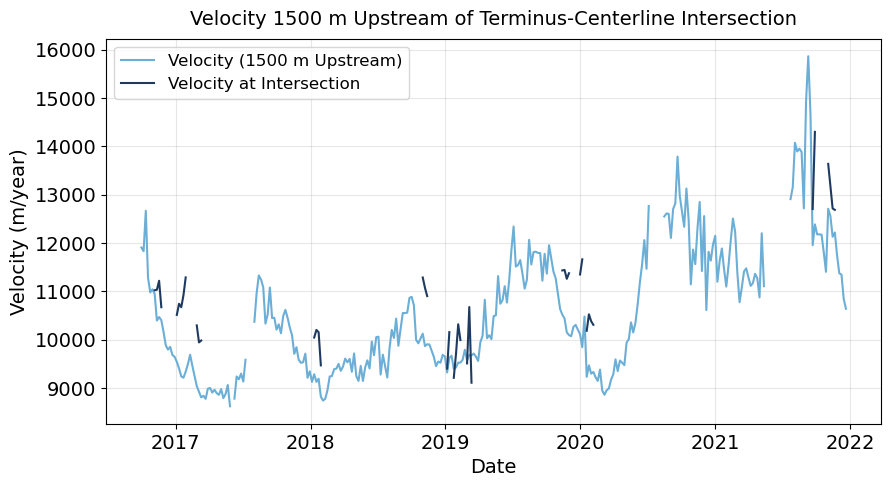

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(terminus["Date"], terminus["vel_up_centreline"], label="Velocity (1500 m Upstream)", color= light_blue)
plt.plot(terminus["Date"], terminus["vel_at_intersection"], label="Velocity at Intersection", color= dark_blue)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Velocity (m/year)", fontsize=14)
plt.title("Velocity 1500 m Upstream of Terminus-Centerline Intersection", fontsize = 14, pad = 10)
plt.xticks(size = 14)
plt.yticks(size = 14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout
plt.show()


For each terminus position:
1. Use the centerline-terminus intersection point
2. Get the length of the upstream segment 

This is Taryn's code - slightly modified

In [24]:
def get_centerline_length(terminus, centerline_extended):
    # ensure terminus data type
    if type(terminus) is LineString:
        pass
    if type(terminus) is pd.Series: #if pd take intersection point (from row)
        pt = terminus["intersect_points"]
    elif type(terminus) is gpd.GeoSeries: # if geoseries take single intersection point (from row)
        pt = terminus["intersect_points"].item()
    else: #if else assume it's already a point geometry
        pt = terminus

#same as tayrns code 
    if type(centerline_extended) is LineString:
        pass
    elif type(centerline_extended) is pd.Series:
        centerline_extended = centerline_extended.geometry
    elif type(centerline_extended) is gpd.GeoSeries:
        centerline_extended = centerline_extended.item()

    if pt is None: #if no valid intersection point return nan
        return np.nan
    
    try:
        d = centerline_extended.project(pt) #distance along the centreline from start to the intersection point
        centerline_length = centerline_extended.length - d

    except:
        centerline_length = np.nan #if anything fails (bad geometry, etc.) return nan

    return centerline_length

# calculate glacier length at centerline for each terminus
terminus["Centerline_Length"] = terminus.apply(get_centerline_length, axis = 1, centerline_extended=centerline_extended_shape)
terminus = terminus[terminus["Centerline_Length"].notna()].copy()

# use the first valid terminus as a baseline
terminus["Centerline_Length"] -= terminus["Centerline_Length"].iloc[0]

In [25]:
# def get_centerline_length(terminus, centerline):
#     # ensure terminus data type
#     if type(terminus) is LineString:
#         pass
#     elif type(terminus) is pd.Series:
#         terminus = terminus.geometry
#     elif type(terminus) is gpd.GeoSeries:
#         terminus = terminus.item()
#     # ensure centerline data type
#     if type(centerline) is LineString:
#         pass
#     elif type(centerline) is pd.Series:
#         centerline = centerline.geometry
#     elif type(centerline) is gpd.GeoSeries:
#         centerline = centerline.item()
#     # split centerline where it intersects with terminus
#     # -- should return a GeometryCollection with two lines
#     # -- note: might want to add an if statement to check for
#     # -- multiple intersections first (unlikely, but possible
#     # -- and will give weird results if so)
#     centerline_parts = shapely.ops.split(geom=centerline, splitter=terminus)
#     try:
#         centerline_upstream = centerline_parts.geoms[1] # <-- index=1 is an assumption! Not sure if it always works - it's probably based on order of coords in centerline
#         centerline_length = centerline_upstream.length
#     except: # <-- if terminus doesn't intersect centerline
#         # centerline_length = pd.NA
#         centerline_length = np.nan
#     return centerline_length

# # calculate glacier length at centerline for each terminus
# terminus["Centerline_Length"] = terminus.apply(get_centerline_length, axis=1, centerline=centerline_shape)
# terminus = terminus[terminus["Centerline_Length"].notna()].copy()

# # use the first valid terminus as a baseline
# terminus["Centerline_Length"] -= terminus["Centerline_Length"].iloc[0]

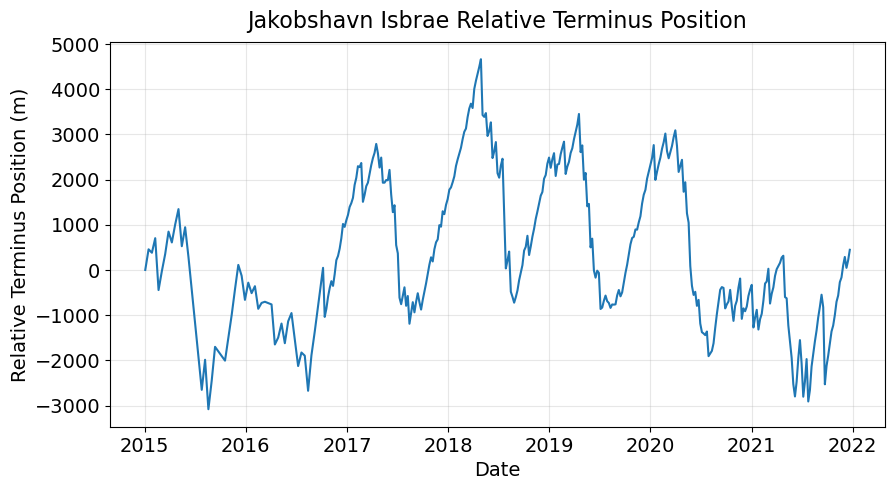

In [26]:
plt.figure(figsize=(10,5))
plt.plot(terminus["Date"], terminus["Centerline_Length"])
plt.title("Jakobshavn Isbrae Relative Terminus Position", fontsize= 16, pad = 10)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Relative Terminus Position (m)", fontsize=14)
plt.xticks(size = 14)
plt.yticks(size = 14)
plt.grid(True, alpha=0.3)
plt.tight_layout
plt.show()


Calculating the difference between expected position (L_expected) and observed position (L):
- Using the the centerline length calculate the expected position based on the previous position
    - i.e., Expected position at time (t) based on the previous position + previous velocity (v) * elapsed time (dt)

In [27]:
# observed terminus position
terminus["L"] = terminus["Centerline_Length"]

# time step
terminus["dt_days"] = terminus["Date"].diff().dt.days
terminus["dt_years"] = terminus["dt_days"] / 365.25

# observed change in terminus position
terminus["dL"] = terminus["L"].diff()
terminus["dLdt"] = terminus["dL"] / terminus["dt_years"]

# expected position at t based on previous position + previous velocity * elapsed time
terminus["L_expected"] = (terminus["L"].shift(1) + terminus["vel_up_centreline"].shift(1) * terminus["dt_years"]
)

# difference between expected and observed position
terminus["expected_minus_observed"] = terminus["L_expected"] - terminus["L"]

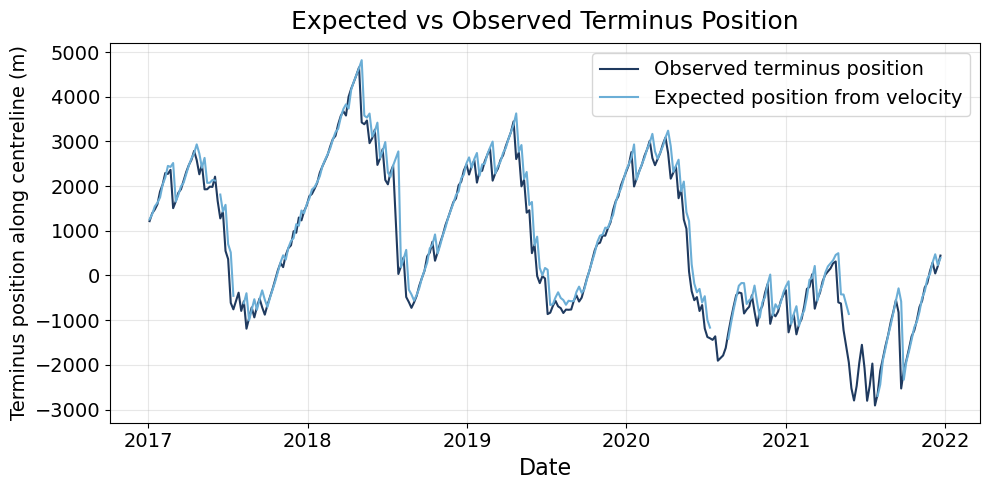

In [28]:
# cut to 2017 bc of limited velocity data before 
terminus_plot = terminus[terminus["Date"] >= "2017"].copy()

plt.figure(figsize=(10, 5))
plt.plot(
    terminus_plot["Date"],
    terminus_plot["L"],
    color=dark_blue,
    label="Observed terminus position"
)
plt.plot(
    terminus_plot["Date"],
    terminus_plot["L_expected"],
    color=light_blue,
    label="Expected position from velocity"
)

plt.xlabel("Date", fontsize=16)
plt.ylabel("Terminus position along centreline (m)", fontsize=14)
plt.title("Expected vs Observed Terminus Position", fontsize=18, pad=10)
plt.xticks(size=14)
plt.yticks(size=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

Calculate the magnitude of calving events, where __calving = velocity x dt - dL__

__Calving events are positive__:
- dLdt > 0 means length is increasing with time - i.e., advance 
- dLdT < 0 means length is decreasing with time - i.e., retreat
    - according to plot dLdt is primarily negative
- vel > 0 flowing towards terminus 

So calving = positve value - negative value, therefore, __calving is positive__ 

In [29]:
terminus["calving"] = terminus["vel_up_centreline"] - terminus["dLdt"]
terminus["calving_magnitude"] = terminus["calving"]/365.25

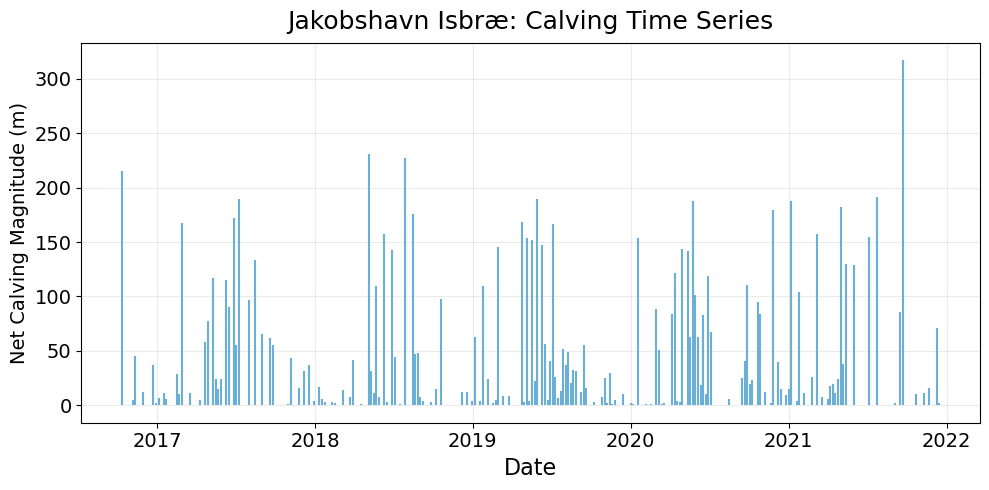

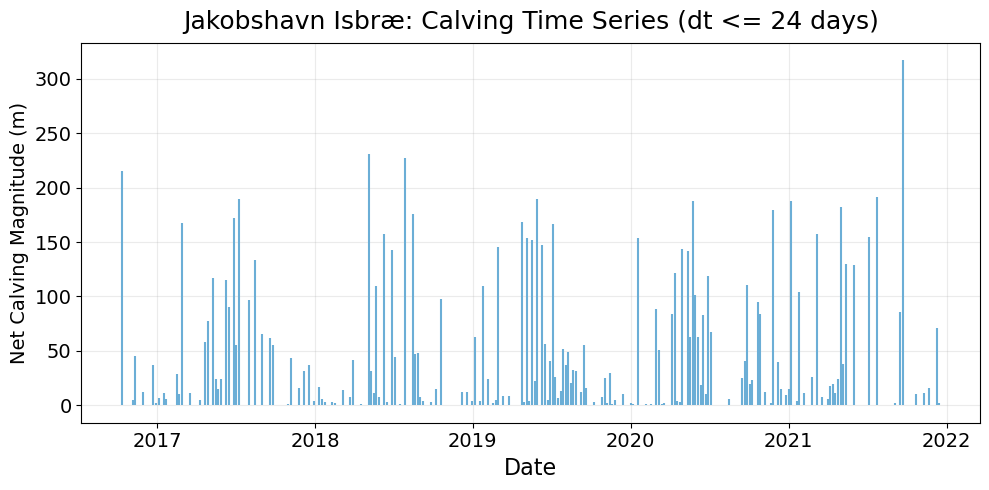

In [51]:
# mask negative values
terminus["calving_positive"] = terminus["calving_magnitude"].where(terminus["calving_magnitude"] > 0)

plt.figure(figsize=(10, 5))
plt.vlines(terminus["Date"], ymin = 0, ymax = terminus["calving_positive"], color=light_blue)
plt.xlabel("Date", fontsize = 16)
plt.ylabel("Net Calving Magnitude (m)", fontsize = 14)
plt.title("Jakobshavn Isbræ: Calving Time Series", fontsize = 18, pad = 10)
plt.grid(True, alpha=0.25)
plt.xticks(size=14)
plt.yticks(size=14)
plt.tight_layout()
    
# mask when dt < 30 days
terminus["calving_filtered"] = terminus["calving_positive"].where(terminus["dt_days"] < 24)

plt.figure(figsize=(10, 5))
plt.vlines(terminus["Date"], ymin = 0, ymax = terminus["calving_filtered"], color=light_blue)
plt.xlabel("Date", fontsize = 16)
plt.ylabel("Net Calving Magnitude (m)", fontsize = 14)
plt.title("Jakobshavn Isbræ: Calving Time Series (dt <= 24 days)", fontsize = 18, pad = 10)
plt.grid(True, alpha=0.25)
plt.xticks(size=14)
plt.yticks(size=14)
plt.tight_layout()


In [31]:
calving_time_series= terminus[["Date", "vel_up_centreline","dLdt","calving","calving_magnitude","dt_days","dt_years", "Centerline_Length"]].copy()
output_path = "/Users/sofiasuhinin/Desktop/GrIS_Calving/Jakobshavn-Isbrae-CalvingStatistics/jakobshavn_calving_length_ts.csv"
calving_time_series.to_csv(output_path, index=False)

#### Step 4: Area change calving time series ####
1. Use centerline velocity to begin with, 
2. Look at how velocity varies along the terminus!

Note: Added modified glacier box size - because I just want to look at the lower trunk bit of JI (where I have the centerline)

In [118]:
#path & read
box_path = "/Users/sofiasuhinin/Desktop/GrIS_Calving/data/MEaSUREs_0781/glacier_boxes_v01.0.shp"
mod_box_path = "/Users/sofiasuhinin/Desktop/GrIS_Calving/data/MEaSUREs_0781/ji_box_mod.shp"

box = gpd.read_file(box_path)
box = box.to_crs("EPSG:3413")
ji_mod_box = gpd.read_file(mod_box_path)
ji_mod_box = ji_mod_box.to_crs("EPSG:3413")

#jakobshavn box
ji_box = box[box["Glacier_ID"] == 3]
print(ji_box.crs)
print(ji_mod_box.crs)

# polygon geometry - just in case i need it
ji_box_polygon = ji_box.geometry.iloc[0]
ji_box_polygon = Polygon(ji_box_polygon)
ji_mod_box_polygon = ji_mod_box.geometry.iloc[0]
ji_mod_box_polygon = Polygon(ji_mod_box_polygon)

#check
print(ji_box.geom_type)
print(ji_box_polygon.geom_type) 
print(ji_mod_box.geom_type)
print(ji_mod_box_polygon.geom_type)

EPSG:3413
EPSG:3413
24    LineString
dtype: object
Polygon
0    LineString
dtype: object
Polygon


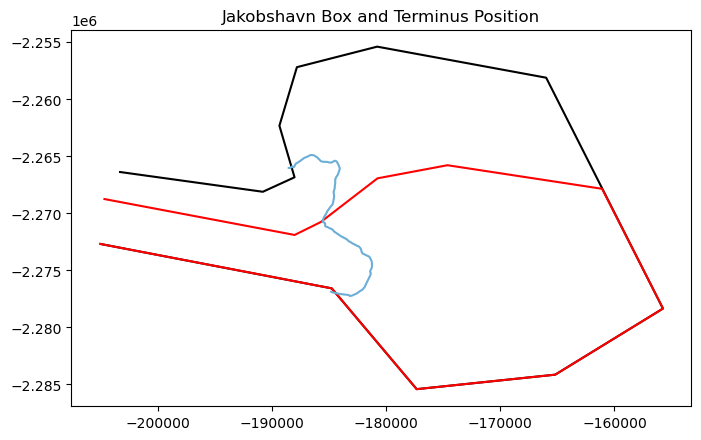

In [110]:
fig, ax = plt.subplots(figsize=(8,8))

ji_box.plot(ax=ax, color="black")
ji_mod_box.plot(ax=ax, color="red")
terminus.iloc[[100]].plot(ax=ax, color=light_blue)
ax.set_title("Jakobshavn Box and Terminus Position")

plt.show()

In [111]:
terminus.columns

Index(['Image_ID', 'Image_Tile', 'Date', 'Flag', 'Glacier_ID', 'geometry',
       'intersect_points', 'vel_at_intersection', 'vel_up_centreline',
       'Centerline_Length', 'L', 'dt_days', 'dt_years', 'dL', 'dLdt',
       'L_expected', 'expected_minus_observed', 'calving', 'calving_magnitude',
       'calving_positive', 'vx_up_centerline', 'vy_up_centerline',
       'calving_filtered'],
      dtype='object')

### 4a. Extracting 'vx' and 'vy'
For now, I am going to use the 'vx' and 'vy' at the point where I got the 'vv' for the previous part from. Later, I can see if there is a better way to go about this!

In [97]:
# velocity data, 3 bands, 'vv', 'vx' and 'vy'
# so now i gotta extract the 'vx' and 'vy' at the point where i got the 'vv' 

print(velocity["band"].values)

vx_band = velocity["VelocityMap"].sel(band = 'vx')
vy_band = velocity["VelocityMap"].sel(band = 'vy')
vv_band = velocity["VelocityMap"].sel(band = 'vv')

# try just using the same velocity extraction method as before

vx_up_centerline = []
vy_up_centerline = []

for i in range(len(terminus)):
    pt = terminus["intersect_points"].iloc[i]
    t_term = pd.to_datetime(terminus["Date"].iloc[i])

    if pt is None:
        vx_up_centerline.append(np.nan)
        vy_up_centerline.append(np.nan)
        continue

    vx_slice = vx_band.sel(time=t_term, method="nearest")
    vy_slice = vy_band.sel(time=t_term, method="nearest")

    # velocity at intersection
    vx0 = vx_slice.sel(x=pt.x, y=pt.y, method="nearest").values
    vy0 = vy_slice.sel(x=pt.x, y=pt.y, method="nearest").values

    # velocity upstream along the same extended centreline
    d0 = centerline_extended_shape.project(pt)

    vx1 = np.nan
    vy1 = np.nan

    for upstream_m in [1500, 2000]: #try this again for consistency
        d1 = d0 + upstream_m

        if d1 > centerline_extended_shape.length:
            continue
        p1 = centerline_extended_shape.interpolate(float(d1))
        vx_test = vx_slice.sel(x=p1.x,y=p1.y,method="nearest").values
        vy_test = vy_slice.sel(x=p1.x,y=p1.y,method="nearest").values

        if np.isfinite(vx_test) and np.isfinite(vy_test):
            vx1 = float(vx_test)
            vy1 = float(vy_test)
            break
    vx_up_centerline.append(vx1)
    vy_up_centerline.append(vy1)

terminus["vx_up_centerline"] = vx_up_centerline
terminus["vy_up_centerline"] = vy_up_centerline

['vx' 'vy' 'vv']


In [98]:
print(terminus[["vx_up_centerline", "vy_up_centerline"]].isna().sum())
print(terminus[["Date", "vx_up_centerline", "vy_up_centerline"]].iloc[50:100])

vx_up_centerline    61
vy_up_centerline    61
dtype: int64
          Date  vx_up_centerline  vy_up_centerline
57  2016-10-30      -7812.935059       7800.457520
58  2016-11-05      -7648.070801       7831.731445
12  2016-11-11      -7157.928711       7536.486328
59  2016-11-17      -7220.079590       7577.096680
60  2016-11-23      -7149.299316       7557.358887
61  2016-11-29      -7026.242188       7336.782227
62  2016-12-05      -6910.702637       7066.105957
63  2016-12-11      -6840.620605       7007.470703
64  2016-12-17      -7055.818848       6871.145508
65  2016-12-23      -6938.156250       6754.847168
66  2016-12-29      -6812.017578       6823.478027
67  2017-01-04      -6636.477539       6852.087402
68  2017-01-10      -6708.661133       6589.458008
69  2017-01-16      -6698.750000       6361.711426
70  2017-01-22      -6614.619629       6409.298340
71  2017-01-28      -6853.774902       6339.739258
1   2017-02-03      -7189.395508       6198.994629
72  2017-02-09      -75

In [119]:
# so now i gotta make predicted terminus lines 
    #https://geopandas.org/en/latest/docs/reference/api/geopandas.GeoSeries.translate.html
# or
# https://shapely.readthedocs.io/en/latest/manual.html - shapely.affinity.translate

#use random index for now 
test = 242

#observed terminus position
terminus_observed_test = terminus.geometry.iloc[test]

# previous terminus position
terminus_previous_test = terminus.geometry.iloc[test-1]

dx = terminus["vx_up_centerline"].iloc[test-1] * terminus["dt_years"].iloc[test]
dy = terminus["vy_up_centerline"].iloc[test-1] * terminus["dt_years"].iloc[test]

# predicted terminus line at current time
predicted_line = translate(terminus_previous_test, xoff=dx, yoff=dy)

# confine terminus lines to the box
observed_clipped = terminus_observed_test.intersection(ji_mod_box_polygon)
predicted_clipped = predicted_line.intersection(ji_mod_box_polygon)

In [123]:
print(type(ji_mod_box_polygon))
print(observed_clipped.geom_type)
print(predicted_clipped.geom_type)

<class 'shapely.geometry.polygon.Polygon'>
LineString
LineString


(-2276955.308900118, -2265784.705199957)

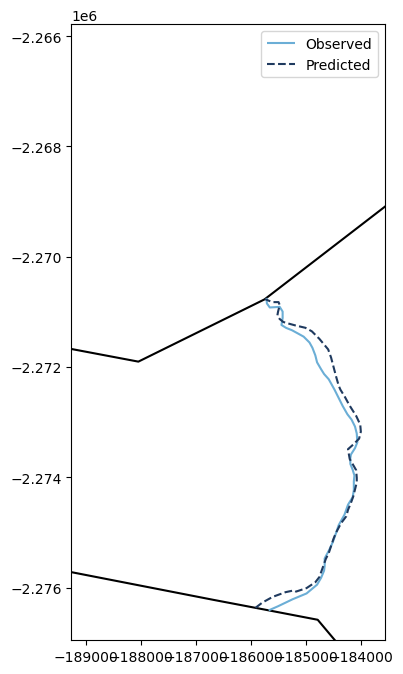

In [124]:
#figure out a better way to plot this 
fig, ax = plt.subplots(figsize=(8, 8))

ji_mod_box.plot(ax=ax, color="black")

#gpd.GeoSeries([terminus_previous_test]).plot(ax=ax,color="gray",label="Previous")
gpd.GeoSeries([observed_clipped]).plot(ax=ax,color=light_blue,label="Observed")
gpd.GeoSeries([predicted_clipped]).plot(ax=ax,color=dark_blue,label="Predicted", linestyle="--")

ax.legend()

# zoom in order to see intersection better
xmin, ymin, xmax, ymax = terminus_observed_test.bounds
zoom = 500
ax.set_xlim(xmin - zoom, xmax + zoom)
ax.set_ylim(ymin - zoom, ymax + zoom)
    

In [126]:
observed_split = split(ji_mod_box_polygon, terminus_observed_test)
predicted_split = split(ji_mod_box_polygon, predicted_line)

observed_polygon = list(observed_split.geoms)
predicted_polygon = list(predicted_split.geoms)

print(len(observed_polygon), len(predicted_polygon))

2 2


### 4b. Finding the area between predicted and observed
For now, treat it as one big bulk polygon area as opposed to multiple sections

In [127]:
# use shapely.ops.split to split the box

observed_split = split(ji_mod_box_polygon, terminus_observed_test) #split 
predicted_split = split(ji_mod_box_polygon, predicted_line) #split

observed_polygon = list(observed_split.geoms)
predicted_polygon = list(predicted_split.geoms)

# glacier side = larger polygon bc it has more area in the box
    #check here
if observed_polygon[0].area > observed_polygon[1].area:
    observed_glacier = observed_polygon[0]
else:
    observed_glacier = observed_polygon[1]

if predicted_polygon[0].area > predicted_polygon[1].area:
    predicted_glacier = predicted_polygon[0]
else:
    predicted_glacier = predicted_polygon[1]

# expected - observed
expected_minus_observed_area = predicted_glacier.area - observed_glacier.area

print("Area change:", expected_minus_observed_area, "m²")
print("Area change:", expected_minus_observed_area / 1e6, "km²")

Area change: -245303.7305009961 m²
Area change: -0.2453037305009961 km²


Area difference: 655141.815228245 m²


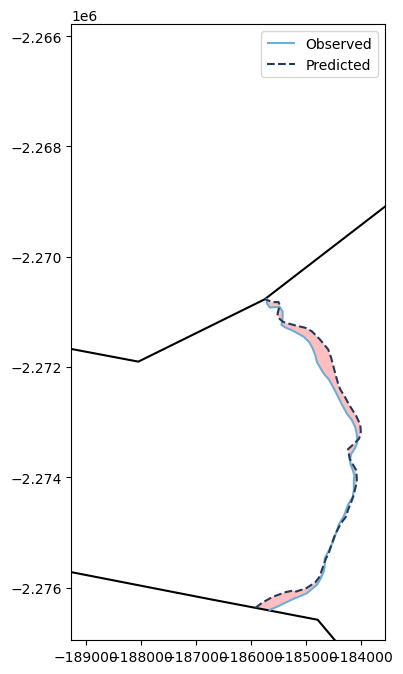

In [129]:
# https://shapely.readthedocs.io/en/2.1.2/reference/shapely.symmetric_difference.html 
area_difference = predicted_glacier.symmetric_difference(observed_glacier)
print("Area difference:", area_difference.area, "m²")

fig, ax = plt.subplots(figsize=(8,8))

ji_mod_box.plot(ax=ax, color="black")

gpd.GeoSeries([area_difference], crs=terminus.crs).plot(ax=ax,color="red",alpha=0.25)
gpd.GeoSeries([observed_clipped], crs=terminus.crs).plot(ax=ax,color=light_blue,label="Observed")
gpd.GeoSeries([predicted_clipped], crs=terminus.crs).plot(ax=ax,color=dark_blue,linestyle="--",label="Predicted")
ax.legend()

# zoom in 
xmin, ymin, xmax, ymax = terminus_observed_test.bounds
zoom = 500
ax.set_xlim(xmin - zoom, xmax + zoom)
ax.set_ylim(ymin - zoom, ymax + zoom)

plt.show()

In [174]:
point = centerline_extended_shape.interpolate(0.05,normalized=True)

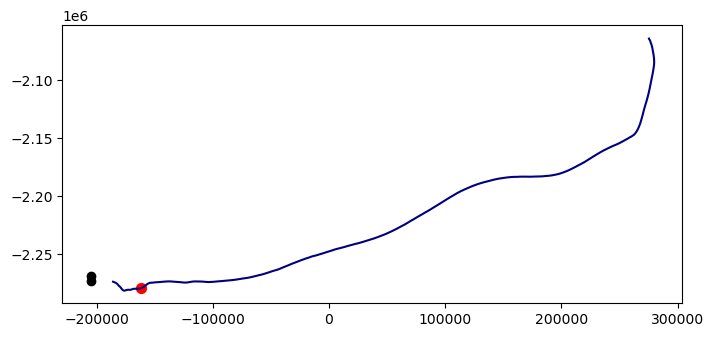

In [175]:
fig, ax = plt.subplots(figsize=(8,8))

ji_mod_box.boundary.plot(ax=ax, color="black")

gpd.GeoSeries([centerline_extended_shape]).plot(
    ax=ax,
    color="navy"
)

gpd.GeoSeries([point]).plot(
    ax=ax,
    color="red",
    markersize=50
)

plt.show()

In [179]:
# attempt at wrapping into a function 
def get_area_change(row, terminus, box_polygon):

    terminus_index = row.name

    if terminus_index == 0:
        area_change = np.nan

    else:
        observed_line = row.geometry
        previous_line = terminus.geometry.iloc[terminus_index - 1]

        dx = terminus["vx_up_centerline"].iloc[terminus_index - 1] * row["dt_years"]
        dy = terminus["vy_up_centerline"].iloc[terminus_index - 1] * row["dt_years"]

        predicted_line = translate(previous_line, xoff=dx, yoff=dy)

        # extracting clean geometries
        clean_box = box_polygon.buffer(0)
        clean_observed = observed_line.buffer(0) if not observed_line.is_valid else observed_line
        clean_predicted = predicted_line.buffer(0) if not predicted_line.is_valid else predicted_line

        try:
            observed_split = split(clean_box, clean_observed)
            predicted_split = split(clean_box, clean_predicted)

            observed_polygon = list(observed_split.geoms)
            predicted_polygon = list(predicted_split.geoms)

            observed_glacier = max(observed_polygon, key=lambda p: p.area)
            predicted_glacier = max(predicted_polygon, key=lambda p: p.area)

            area_change = predicted_glacier.area - observed_glacier.area

        except:
            area_change = np.nan

    return area_change

terminus["area_change_m2"] = terminus.apply(get_area_change, axis=1, terminus=terminus, box_polygon=ji_mod_box_polygon)
terminus["area_change_km2"] = terminus["area_change_m2"] / 1e6

terminus["calving_area_m2"] = terminus["area_change_m2"].where((terminus["area_change_m2"] > 0) & (terminus["area_change_m2"] < 20e6))
terminus["calving_area_km2"] = terminus["calving_area_m2"] / 1e6

print(terminus["area_change_km2"].notna().sum())

295


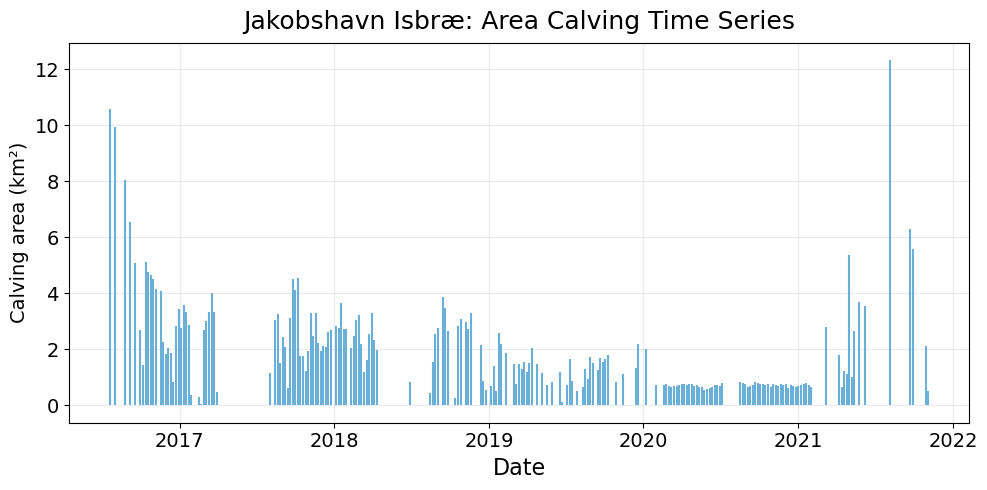

In [180]:
plt.figure(figsize=(10, 5))

plt.vlines(terminus["Date"], ymin=0, ymax=terminus["calving_area_km2"], color=light_blue)
plt.xlabel("Date", fontsize=16)
plt.ylabel("Calving area (km²)", fontsize=14)
plt.title("Jakobshavn Isbræ: Area Calving Time Series", fontsize=18, pad=10)
plt.grid(True, alpha=0.25)
plt.xticks(size=14)
plt.yticks(size=14)
plt.tight_layout()

In [181]:
def plot_calving(i):
    terminus_observed = terminus.geometry.iloc[i]
    terminus_previous = terminus.geometry.iloc[i - 1]

    dx = terminus["vx_up_centerline"].iloc[i - 1] * terminus["dt_years"].iloc[i]
    dy = terminus["vy_up_centerline"].iloc[i - 1] * terminus["dt_years"].iloc[i]

    predicted_line = translate(terminus_previous, xoff=dx, yoff=dy)

    # split box using full lines
    observed_split = split(ji_mod_box_polygon, terminus_observed)
    predicted_split = split(ji_mod_box_polygon, predicted_line)

    observed_glacier = max(list(observed_split.geoms), key=lambda p: p.area)
    predicted_glacier = max(list(predicted_split.geoms), key=lambda p: p.area)

    area_difference = predicted_glacier.difference(observed_glacier)

    # clip lines for plotting only
    observed_clipped = terminus_observed.intersection(ji_mod_box_polygon)
    predicted_clipped = predicted_line.intersection(ji_mod_box_polygon)

    fig, ax = plt.subplots(figsize=(8, 8))

    gpd.GeoSeries([ji_mod_box_polygon]).boundary.plot(ax=ax, color="black")
    gpd.GeoSeries([area_difference]).plot(ax=ax, color="pink", alpha=0.5)
    gpd.GeoSeries([observed_clipped]).plot(ax=ax, color=light_blue, label="Observed")
    gpd.GeoSeries([predicted_clipped]).plot(ax=ax, color=dark_blue, linestyle="--", label="Predicted")

    ax.legend()

    xmin, ymin, xmax, ymax = observed_clipped.bounds
    zoom = 500

    ax.set_xlim(xmin - zoom, xmax + zoom)
    ax.set_ylim(ymin - zoom, ymax + zoom)

    plt.show()

    print("Area difference:",(predicted_glacier.area - observed_glacier.area) / 1e6,"km²")

In [182]:
terminus["Date"].iloc[260]

Timestamp('2020-05-12 00:00:00')

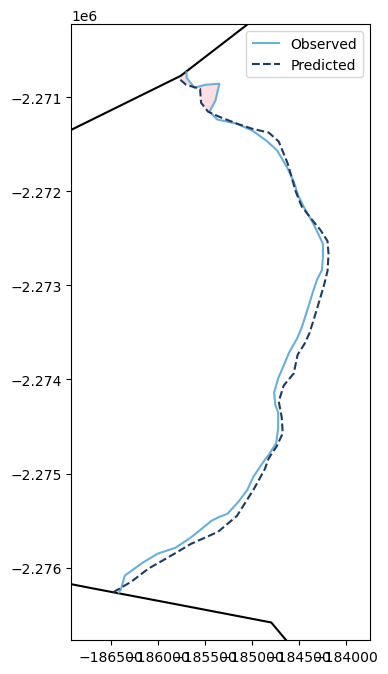

Area difference: -0.32897664523637293 km²


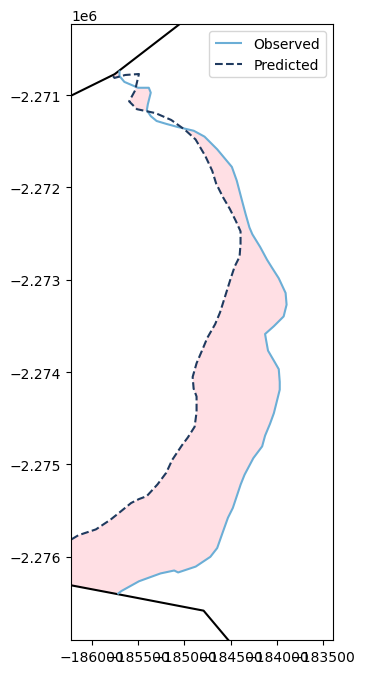

Area difference: 3.6093288166952133 km²


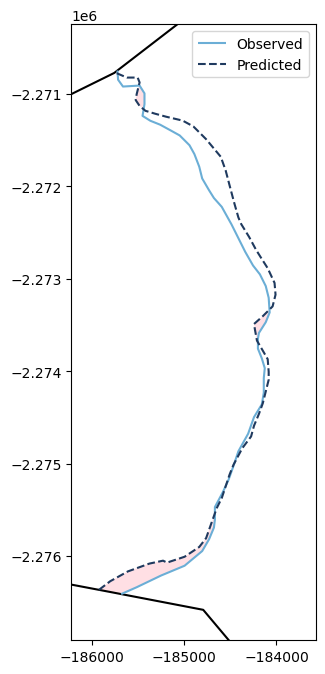

Area difference: -0.2453037305009961 km²


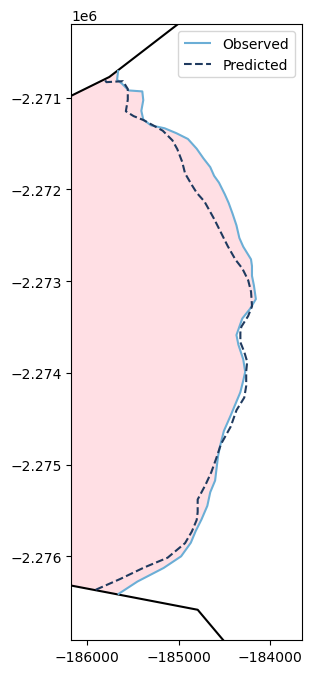

Area difference: 85.56032709314704 km²


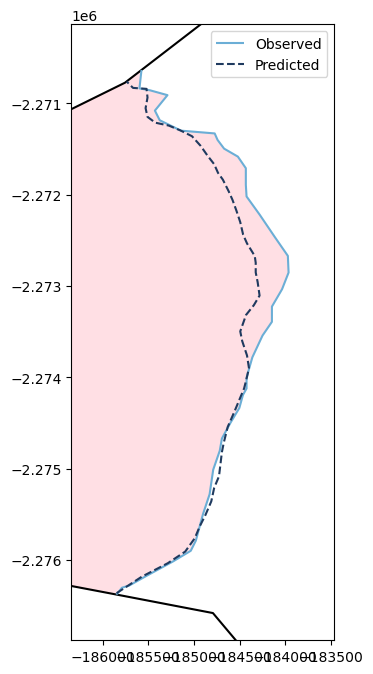

Area difference: 85.57217267220885 km²


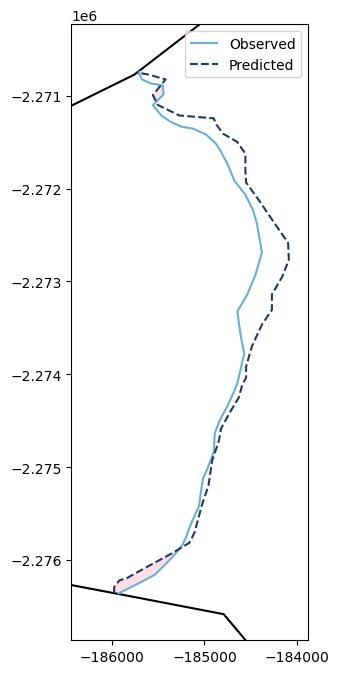

Area difference: -0.6626033322636485 km²


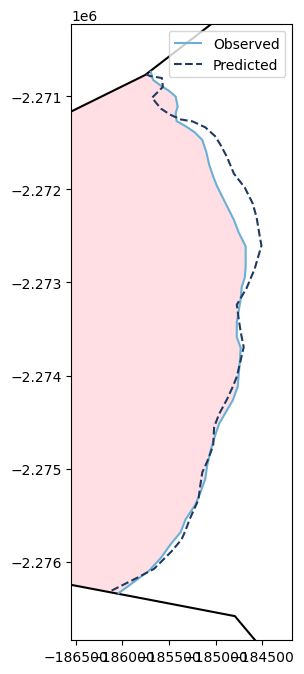

Area difference: 83.12927617435598 km²


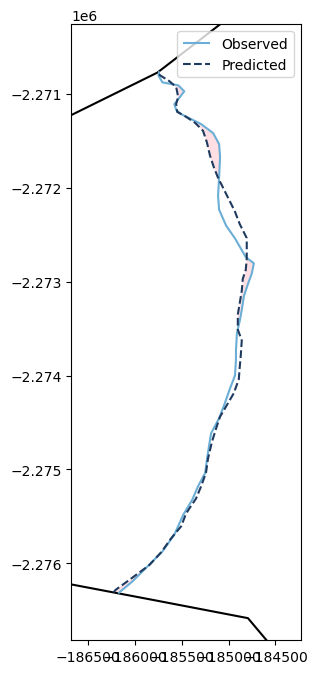

Area difference: -0.055327982595980166 km²


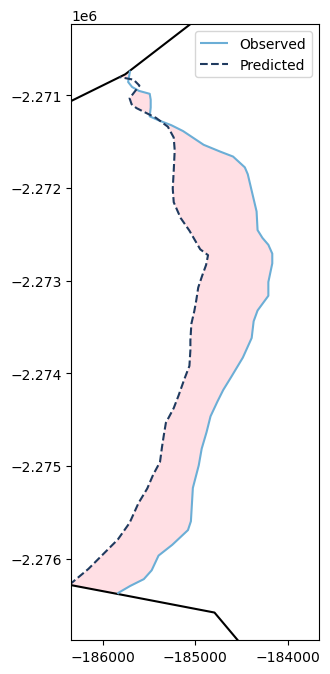

Area difference: 3.0924901186901925 km²


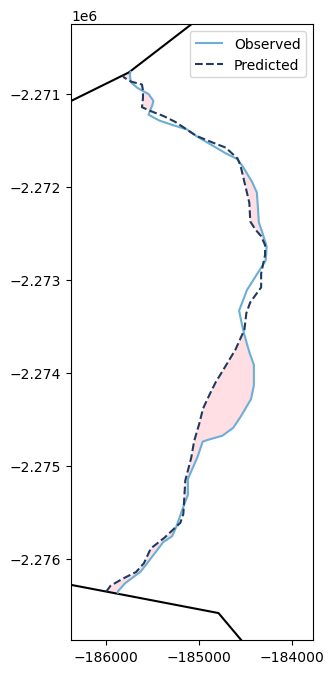

Area difference: 0.43915328684234617 km²


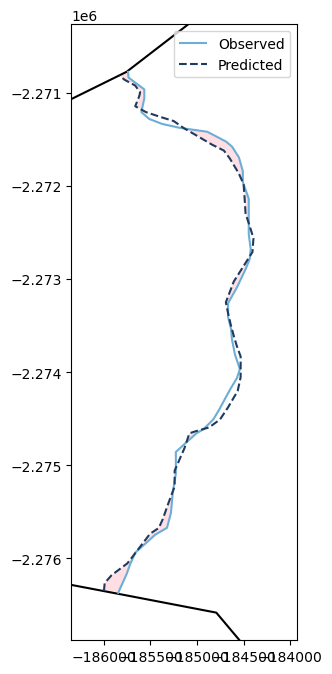

Area difference: 0.10599993440926075 km²


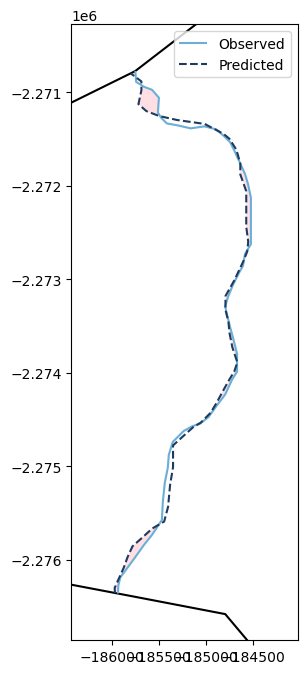

Area difference: 0.07410814006501436 km²


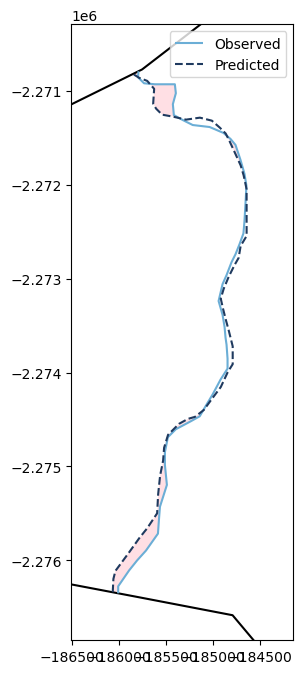

Area difference: 0.1245870736835599 km²


In [183]:
plot_calving(240)
plot_calving(241)
plot_calving(242)
plot_calving(243)
plot_calving(244)
plot_calving(245)
plot_calving(246)
plot_calving(247)
plot_calving(248)
plot_calving(249)
plot_calving(250)
plot_calving(251)
plot_calving(252)

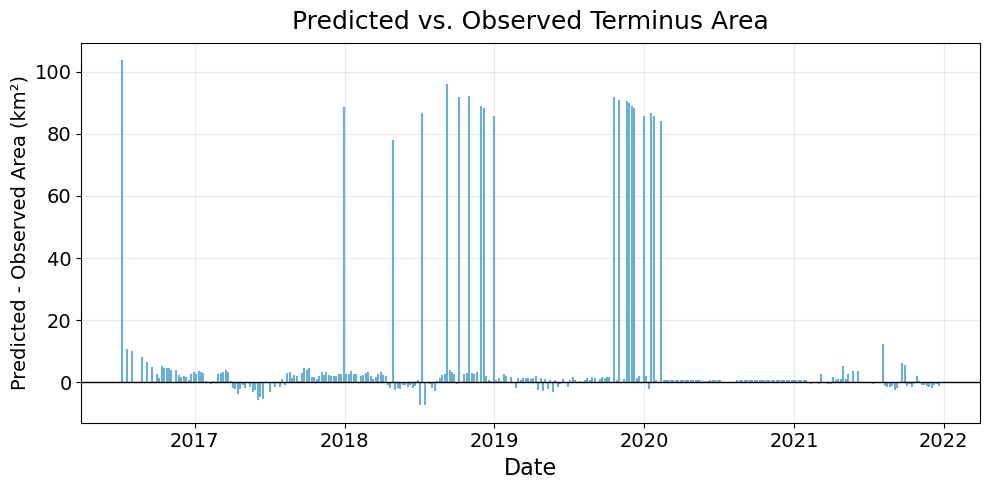

In [142]:
plt.figure(figsize=(10, 5))

plt.vlines(
    terminus["Date"],
    ymin=0,
    ymax=terminus["area_change_km2"],
    color=light_blue
)

plt.axhline(0, color="black", linewidth=1)

plt.xlabel("Date", fontsize=16)
plt.ylabel("Predicted - Observed Area (km²)", fontsize=14)
plt.title("Predicted vs. Observed Terminus Area", fontsize=18, pad=10)

plt.grid(True, alpha=0.25)
plt.xticks(size=14)
plt.yticks(size=14)
plt.tight_layout()

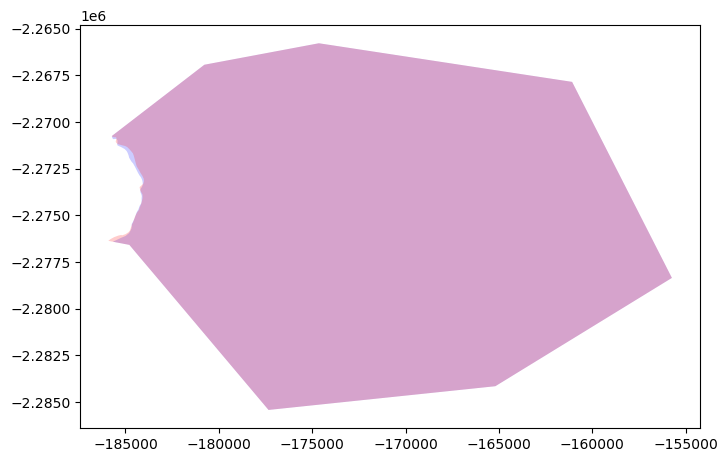

In [164]:
fig, ax = plt.subplots(figsize = (8,8))

gpd.GeoSeries([observed_glacier]).plot(ax=ax, color="blue", alpha=0.2)
gpd.GeoSeries([predicted_glacier]).plot(ax=ax, color="red", alpha=0.2)

plt.show()